In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface

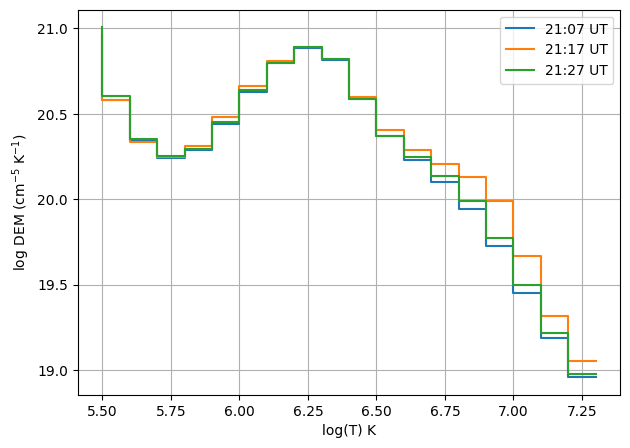

In [15]:
fig=plt.figure(figsize=(7,5))
ax7=fig.add_subplot()

#分别选取21：07，21：17，21：24三个时刻
time_list=['21_07_06','21_17_06','21_27_06']
avg_dem_list=[]
for i in range(3):
    data=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\DEM18-Jun-2024_'+time_list[i]+'.sav')
    result=data['result']
    dem_out=result['DEM_OUT'][0]
    dem_out_2=dem_out[:19,:,:]
    avg_dem=np.mean(dem_out_2,axis=(1,2))
    avg_dem_list.append(avg_dem)

x_arr=np.linspace(5.5,7.3,19)
for i, label in enumerate(['21:07 UT', '21:17 UT', '21:27 UT']):
    ax7.step(
        x_arr,
        np.log10(avg_dem_list[i]),
        label=label
    )

ax7.legend(loc='upper right', fontsize=10)
#ax7.text(0.02,0.9,'(g)',color='black',transform=ax7.transAxes,fontsize=12)
ax7.set_ylabel('log DEM (cm$^{-5}$ K$^{-1}$)')
ax7.set_xlabel('log(T) K')
ax7.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax7.grid(True)

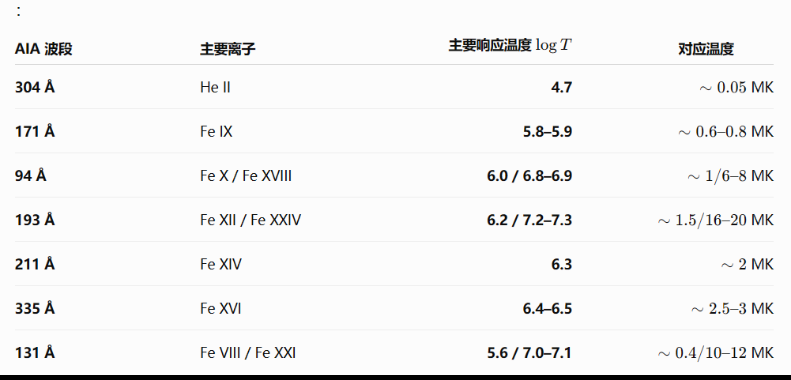

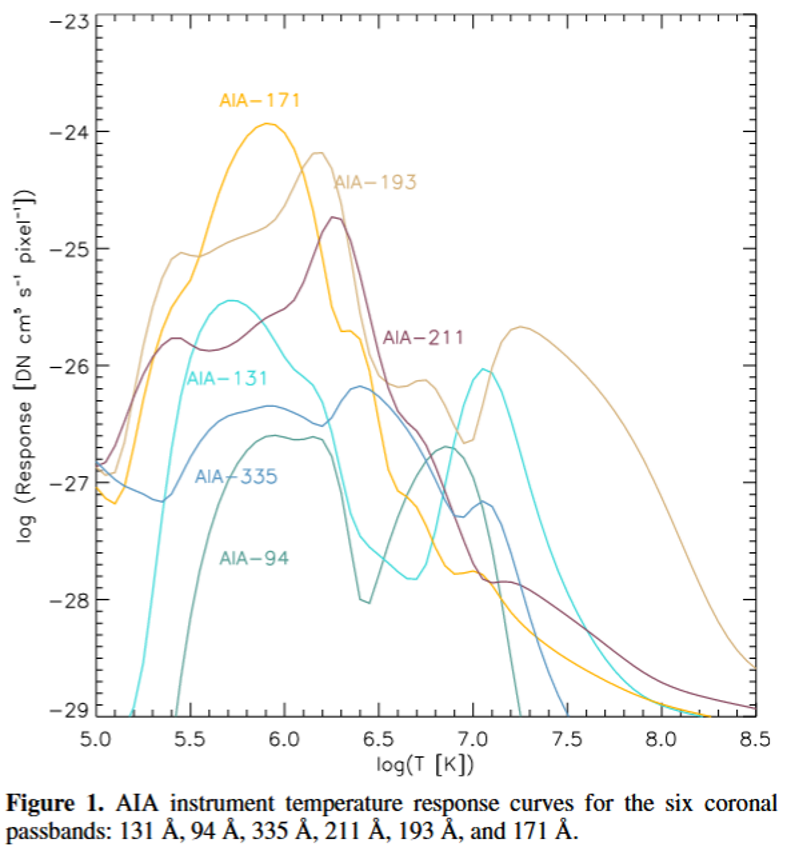  

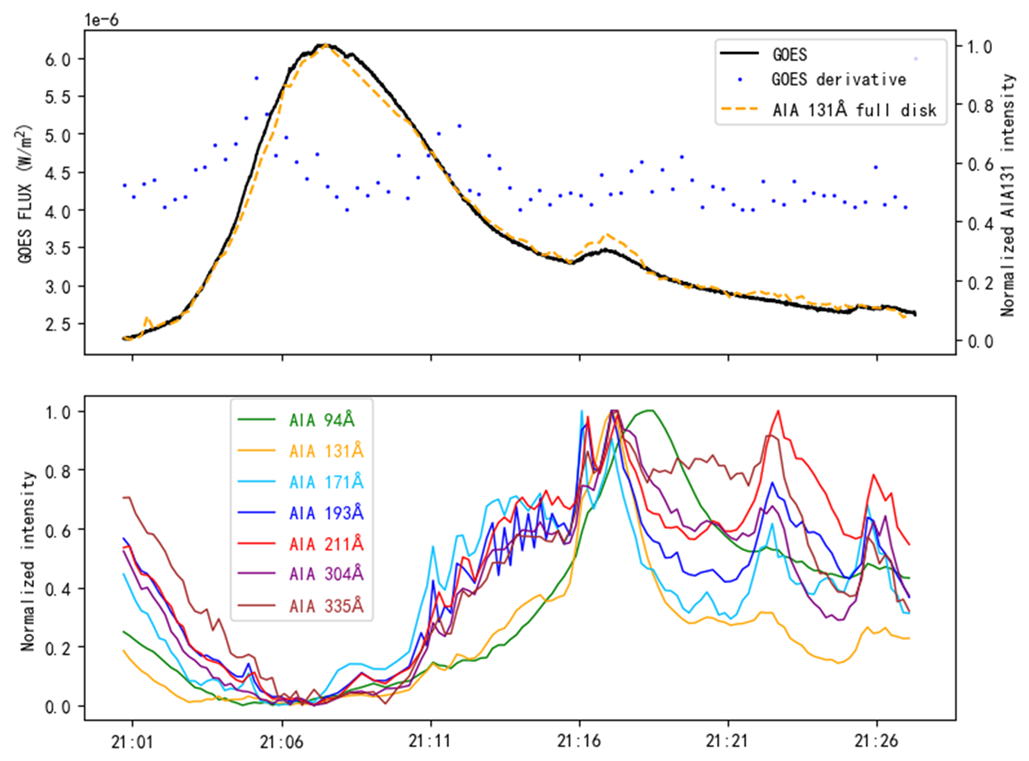

没辙了，重新用Python跑一遍算AIA的强度吧  
结果是一样的  
我这也不是单一

In [ ]:
ref_map=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits')
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=ref_map.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=ref_map.coordinate_frame)
ref_sub_map=ref_map.submap(bottom_left,top_right=top_right)

root_dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'
name_list=['.94','131','171','193','211','304','335']
save_dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\\'
for i in range(7):
    matrix=[]
    file_list=glob.glob(root_dir+name_list[i]+'\\*.fits')
    for j in range(len(file_list)):
        map_temp=sunpy.map.Map(file_list[j])
        with propagate_with_solar_surface():
            smap_temp=map_temp.reproject_to(ref_sub_map.wcs,preserve_date_obs=True)
        matrix.append(smap_temp)
    

In [22]:
from pathlib import Path
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface

root_dir = Path(
    r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2'
)
save_dir = Path(
    r'C:\Learning\PHD1st\magnetic_reconnecion\data_process'
)

# '.94' 按你的原代码保留；如果实际文件夹叫 '94'，这里也改成 '94'
name_list = ['.94', '131', '171', '193', '211', '304', '335']

for name in name_list:
    matrix = []
    channel_dir = save_dir / name
    channel_dir.mkdir(parents=True, exist_ok=True)
    file_list = sorted((root_dir / name).glob('*.fits'))

    for file_path in file_list:
        map_temp = sunpy.map.Map(str(file_path))
        with propagate_with_solar_surface():
            smap_temp = map_temp.reproject_to(ref_sub_map.wcs, preserve_date_obs=True)

        # 补回曝光时长、波长、单位及仪器信息，保留重投影后的 WCS
        meta = smap_temp.meta.copy()
        for key in ['exptime', 'xposure', 'timeunit', 'wavelnth', 'waveunit', 'instrume', 'telescop', 'detector', 'obsrvtry', 'bunit']:
            if key in map_temp.meta:
                meta[key] = map_temp.meta[key]

        smap_temp = sunpy.map.Map(smap_temp.data, meta)
        matrix.append(smap_temp)
        smap_temp.save(str(channel_dir / file_path.name), overwrite=True)

In [9]:
intensity_all=np.zeros((7,148))
name_list=['.94','131','171','193','211','304','335']
exp_time=np.zeros((7,148))
for i in range(7):
    file_name_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\\'+name_list[i]+'\\*.fits')
    intensity=np.zeros(148)
    for j in range(148):
        rsm=fits.open(file_name_list[j])
        exp_time[i,j]=rsm[0].header['exptime']
        intensity[j]=rsm[0].data.mean()
    if name_list[i]=='131' or '193':
        threshold=2.90 if name_list[i]=='131' else 1.99
        intensity[exp_time[i,:]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(148)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    intensity_all[i,:]=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))

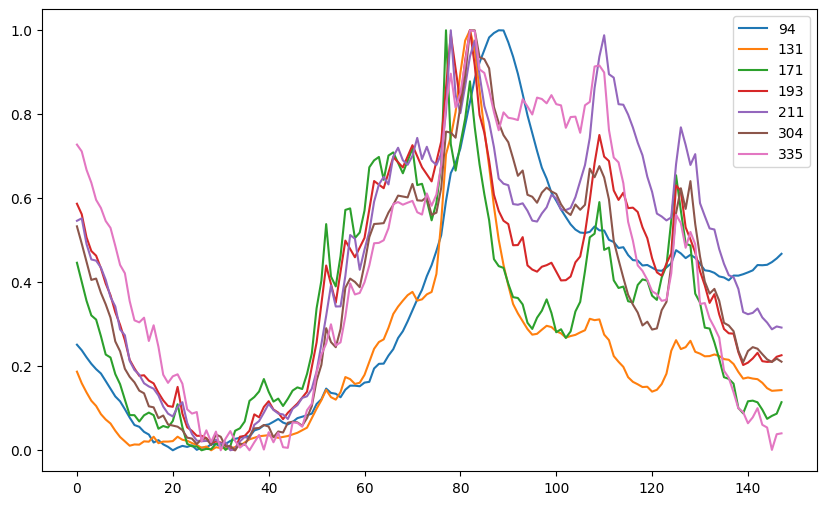

In [11]:
plt.figure(figsize=(10,6))
plt.plot(intensity_all[0,:],label='94')
plt.plot(intensity_all[1,:],label='131')
plt.plot(intensity_all[2,:],label='171')
plt.plot(intensity_all[3,:],label='193')
plt.plot(intensity_all[4,:],label='211')
plt.plot(intensity_all[5,:],label='304')
plt.plot(intensity_all[6,:],label='335')
plt.legend()

这一小段代码是顺带画一下304，看看底下有没有mini-filament

In [12]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\304\*.fits')
for i in range(len(file_list)):
    map304=sunpy.map.Map(file_list[i])
    map304.plot()
    plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\304fig\\'+str(i)+'.png',dpi=300)
    plt.close()


In [13]:
print(0.2/6562.8*3*10**5)

9.1424392027793
